# Testing Qpr calculations when elongating the grating

In [12]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')

import torch

import autolib 
import fom
from parameters import D1_ND, Parameters
from twobox import TwoBox
from ilic import *

npa = autolib.AutoLib('torch')
npaa = autolib.AutoLib('autograd')

# Ilic grating

In [13]:
 ## Ilic
wavelength      = 1.5 #/ D1_ND(1.2/100)
grating_pitch   = 1.8 / wavelength
grating_depth   = 0.5 / wavelength
box1_width      = 0.15 * grating_pitch
box2_width      = 0.35 * grating_pitch
box_centre_dist = 0.60 * grating_pitch
box1_eps        = 3.5**2 
box2_eps        = 3.5**2
gaussian_width  = 2* 10   # 2.7180049942915896 * 10
substrate_depth = 0.5 / wavelength
substrate_eps   = 1.45**2

wavelength      = 1.
angle           = 0.
Nx              = 300
numG            = 12
Qabs            = np.inf

gratingGRCWA = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
                 gaussian_width, substrate_depth, substrate_eps,
                 wavelength, angle, Nx, numG, Qabs, RCWA_engine='GRCWA')
numGTorcwa = numG
gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
                 gaussian_width, substrate_depth, substrate_eps,
                 wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)

# Qpr2 and elongation testing

In [14]:
# from copy import deepcopy as deepcopy
# from flex import Qpr2_elongated, dQpr2_dscale

# box_centre_dist = 0.15*grating_pitch
# gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
#                  gaussian_width, substrate_depth, substrate_eps,
#                  wavelength, angle, Nx, 12, Qabs, RCWA_engine='TORCWA', torcwa_edge_sharpness=50)

# Qpr2_base = gratingTorcwa.Q()[1]
# print('Qpr2 base = ',Qpr2_base)
# print(gratingTorcwa.params)

# scale = torch.tensor(1.)
# Qpr2_unscaled = Qpr2_elongated(gratingTorcwa, scale)
# print('Qpr2 unscaled = ',Qpr2_unscaled)
# print(gratingTorcwa.params)

# # _ = gratingTorcwa.show_permittivity()

# PDQpr2_PDscale = dQpr2_dscale(gratingTorcwa, scale)
# print('Automatic diff dQpr2/dscale at scale=1 = ',PDQpr2_PDscale)

# h = 1e-4
# scale_plus = 1. + h
# Qpr2_plus = Qpr2_elongated(gratingTorcwa, scale_plus)
# scale_minus = 1. - h
# Qpr2_minus = Qpr2_elongated(gratingTorcwa, scale_minus)
# PDQpr2_PDscale_FD = (Qpr2_plus - Qpr2_minus) / (2.*h)
# print('Finite difference dQpr2/dscale at scale=1 = ',PDQpr2_PDscale_FD)

# scale=1.1
# Qpr2_scaled = Qpr2_elongated(gratingTorcwa, scale)
# print('Qpr2 scaled = ',Qpr2_scaled)
# print(gratingTorcwa.params)

# # _ = gratingTorcwa.show_permittivity()

In [15]:
final_speed = 15.
# average_kpr = fom.multifom_minimum_adp(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=0.1, return_grad=False)
# print(f'Adp kpr min after speed {final_speed}%c = {average_kpr}')

# average_kpr = fom.multifom_minimum(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=100, return_grad=True)
# print(f'Man kpr min after speed {final_speed}%c = {average_kpr}')

# _ = gratingTorcwa.show_FOM_spectrum(fom.monofom_elongation, angle=0., wavelength_range=(1.,1.2), num_plot_points=100)

### Minimum kpr figure of merit vs number of samples

#### Finite difference target

In [16]:
# final_speed = 15.

# goal = 0.01
# params = gratingTorcwa.params
# h = 1e-6
# fom_grad = np.zeros(len(gratingTorcwa.params))
# for idx, p in enumerate(gratingTorcwa.params):
#     params_plus = params[:]
#     params_minus = params[:]
#     params_plus[idx] = p + h
#     params_minus[idx] = p - h
#     gratingplus = TwoBox(*params_plus, wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)
#     gratingminus = TwoBox(*params_minus, wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)
#     fom_plus = fom.multifom_minimum_adp(gratingplus, monofom=fom.monofom_elongation, final_speed=final_speed, goal=goal, return_grad=False)
#     fom_minus = fom.multifom_minimum_adp(gratingminus, monofom=fom.monofom_elongation, final_speed=final_speed, goal=goal, return_grad=False)
#     fom_grad[idx] = (fom_plus - fom_minus)/(2.*h)

# fig, ax = plt.subplots(1,figsize=(7,5))
# param_labels = ['Grating pitch', 'Grating depth', 'Box 1 width', 'Box 2 width', 'Box centre dist', 'Box 1 eps', 'Box 2 eps', 'Gaussian width', 'Substrate depth', 'Substrate eps']
# colors = plt.cm.viridis(np.linspace(0,1,len(gratingTorcwa.params)))
# for i in range(len(gratingTorcwa.params)):
#     ax.axhline(y=fom_grad[i], color=colors[i], linestyle='--')

# ax.set(ylabel='Gradient component')
# ax.set_yscale('symlog', linthresh=1e-1)
# ax.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)
# fig.savefig(f"./Data/kpr convergence/kpr_finite_grad.pdf", bbox_inches='tight')

#### Adaptive sampling convergence

In [17]:
# final_speed = 15.
# goals = np.logspace(-2,-1,10)

# fom_grads = np.zeros((len(goals),len(gratingTorcwa.params)))
# for idx, goal in enumerate(goals):
#     gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
#                             gaussian_width, substrate_depth, substrate_eps,
#                             wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)
#     fom_grads[idx] = fom.multifom_minimum_adp(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=goal, return_grad=True)[1]

# fig, ax = plt.subplots(1,figsize=(7,5))

# param_labels = ['Grating pitch', 'Grating depth', 'Box 1 width', 'Box 2 width', 'Box centre dist', 'Box 1 eps', 'Box 2 eps', 'Gaussian width', 'Substrate depth', 'Substrate eps']
# colors = plt.cm.viridis(np.linspace(0,1,len(gratingTorcwa.params)))
# for i in range(len(gratingTorcwa.params)):
#     ax.plot(goals, fom_grads[:,i], color=colors[i], marker='o', label=param_labels[i])

# ax.set(xlabel='Number of samples', ylabel='Gradient component')
# ax.set_yscale('symlog', linthresh=1e-1)
# ax.set_xscale('log')
# ax.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)
# # fig.savefig(f"./Data/kpr convergence/kpr_adaptive_grad_convergence_goal{goal[0]}_{goal[-1]}.pdf", bbox_inches='tight')

#### Grid sampling convergence

In [18]:
# final_speed = 15.
# n_samples = np.arange(200,400,50)

# gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
#                         gaussian_width, substrate_depth, substrate_eps,
#                         wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)
# target_fom_grad = fom.multifom_minimum_adp(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=0.01, return_grad=True)[1]

# fom_grads = np.zeros((len(n_samples),len(gratingTorcwa.params)))
# for idx, n in enumerate(n_samples):
#     gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
#                             gaussian_width, substrate_depth, substrate_eps,
#                             wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)
#     fom_grads[idx] = fom.multifom_minimum(gratingTorcwa, monofom=fom.monofom_elongation, final_speed=final_speed, goal=n, return_grad=True)[1]

# fig, ax = plt.subplots(1,figsize=(7,5))

# param_labels = ['Grating pitch', 'Grating depth', 'Box 1 width', 'Box 2 width', 'Box centre dist', 'Box 1 eps', 'Box 2 eps', 'Gaussian width', 'Substrate depth', 'Substrate eps']
# colors = plt.cm.viridis(np.linspace(0,1,len(gratingTorcwa.params)))
# for i in range(len(gratingTorcwa.params)):
#     ax.plot(n_samples, fom_grads[:,i], color=colors[i], marker='o', label=param_labels[i])
#     ax.axhline(y=target_fom_grad[i], color=colors[i], linestyle='--')

# ax.set(xlabel='Number of samples', ylabel='Gradient component')
# ax.set_xticks(n_samples)
# ax.set_yscale('symlog', linthresh=1e-1)
# ax.legend(bbox_to_anchor=(1.05, 0.5), loc='center left', frameon=False)
# fig.savefig(f"./Data/kpr convergence/kpr_grid_grad_convergence_n{n_samples[0]}_{n_samples[-1]}.pdf", bbox_inches='tight')

### Maximum kpr figure of merit

#### Gradient test

In [19]:
params = gratingTorcwa.params
h = 1e-6
fom_grad = np.zeros(len(gratingTorcwa.params))
for idx, p in enumerate(gratingTorcwa.params):
    params_plus = params[:]
    params_minus = params[:]
    params_plus[idx] = p + h
    params_minus[idx] = p - h
    gratingplus = TwoBox(*params_plus, wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)
    gratingminus = TwoBox(*params_minus, wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)
    fom_plus = fom.multifom_monochrome(gratingplus, monofom=fom.monofom_kpr_unstable, return_grad=False)
    fom_minus = fom.multifom_monochrome(gratingminus, monofom=fom.monofom_kpr_unstable, return_grad=False)
    fom_grad[idx] = (fom_plus - fom_minus)/(2.*h)

kpr_unstable_autograd = fom.multifom_monochrome(gratingTorcwa, monofom=fom.monofom_kpr_unstable, return_grad=True)[1]

print('Finite difference kpr_unstable gradient = ',fom_grad)
print('Autograd kpr_unstable gradient = ',kpr_unstable_autograd)

Finite difference kpr_unstable gradient =  [ -8.78526892  52.59243473 -61.85859028 -47.01401832   4.42802946
   1.00972303  -1.75466083   0.          62.12232381   7.98625738]
Autograd kpr_unstable gradient =  [ -8.78526895  52.59244011 -61.85859012 -47.014005     4.42802954
   1.00972294  -1.75466082   0.          62.1223238    7.98625738]


#### FOM convergence vs nG

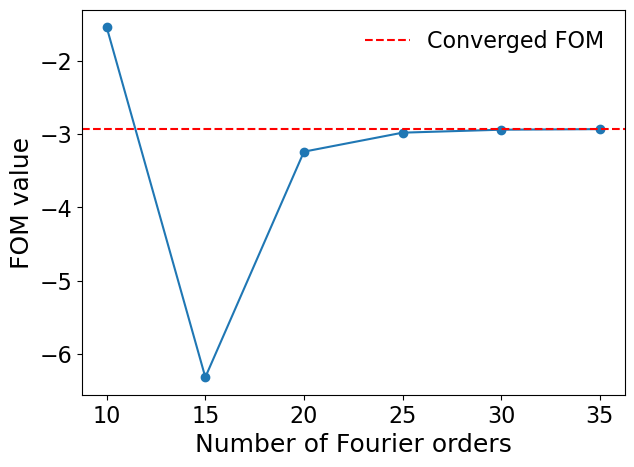

In [34]:
grating_pitch   = 1.9899957270606539
grating_depth   = 2.999994020103646
box1_width      = 1.2549317871938406
box2_width      = 1.9999953815956335
box_centre_dist = 0.3375855400072206
box1_eps        = 12.249969470923872
box2_eps        = 12.249942685120752
gaussian_width  = 20.0
substrate_depth = 2.7252615273996965
substrate_eps   = 12.249947930632167
``
# params = gratingTorcwa.params
params = [grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, gaussian_width, substrate_depth, substrate_eps]

Nx = 1000
nGs = np.arange(10,40,5)
# nGs = np.arange(10,200,20)
foms = np.zeros(len(nGs))
grating_copy = TwoBox(*params, wavelength, angle, Nx=Nx, nG=12, Qabs=Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)
for idx, nG in enumerate(nGs):
    grating_copy.nG = nG
    foms[idx] = fom.multifom_monochrome(grating_copy, monofom=fom.monofom_kpr_unstable, return_grad=False)

grating_copy.Nx = 1000
grating_copy.nG = 200
fom_converged = fom.multifom_monochrome(grating_copy, monofom=fom.monofom_kpr_unstable, return_grad=False)

fig, ax = plt.subplots(1,figsize=(7,5))
ax.plot(nGs, foms, marker='o')
ax.set(xlabel='Number of Fourier orders', ylabel='FOM value')
ax.axhline(y=fom_converged, color='r', linestyle='--', label='Converged FOM')
ax.legend(frameon=False)
fig.savefig(f"./Data/kpr_unstable convergence/kpr_unstable_fom_vs_nG{nGs[0]}_{nGs[-1]}_Nx{Nx}.pdf", bbox_inches='tight')